In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
result_dir = "/home/swim/bo-ptycho/results/Si2V1_2/260817"
train_x = np.load(os.path.join(result_dir, 'train_x.npy')).T
train_y = np.load(os.path.join(result_dir, 'train_y.npy')).T
print(train_x.shape)

EPSILON = 1e-4
START   = 64
END     = None

xparams = [
    'defocus [A]',
    'layers',
    'thickness [A]'
]

(3, 576)


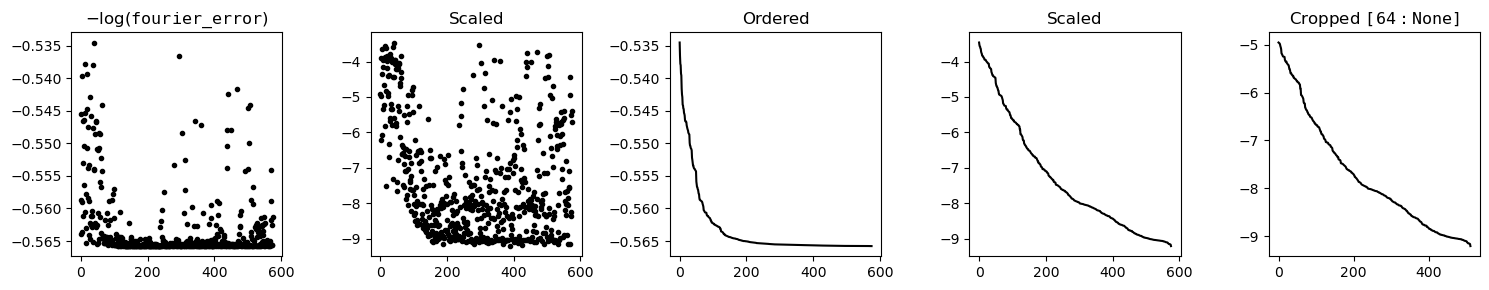

In [3]:
sort_index = np.argsort(train_y)
x = train_x[:,sort_index]
y = train_y[sort_index]
y_scaled = np.log(-y + y[-1] + EPSILON)
train_y_scaled = np.log(-train_y + y[-1] + EPSILON)

fig, ax = plt.subplots(1, 5, figsize=(15,3))
ax[0].plot(-train_y, 'k.')
ax[0].set_title("$-\\log(\\mathtt{fourier\\_error})$")
ax[1].plot(train_y_scaled, 'k.')
ax[1].set_title("Scaled")
ax[2].sharey(ax[0])
ax[2].plot(-y, 'k')
ax[2].set_title("Ordered")
ax[3].plot(y_scaled, 'k')
ax[3].set_title("Scaled")
ax[4].plot(y_scaled[START:END], 'k')
ax[4].set_title(f"Cropped $\\mathtt{{[{START}:{END}]}}$")
plt.tight_layout()
plt.show()

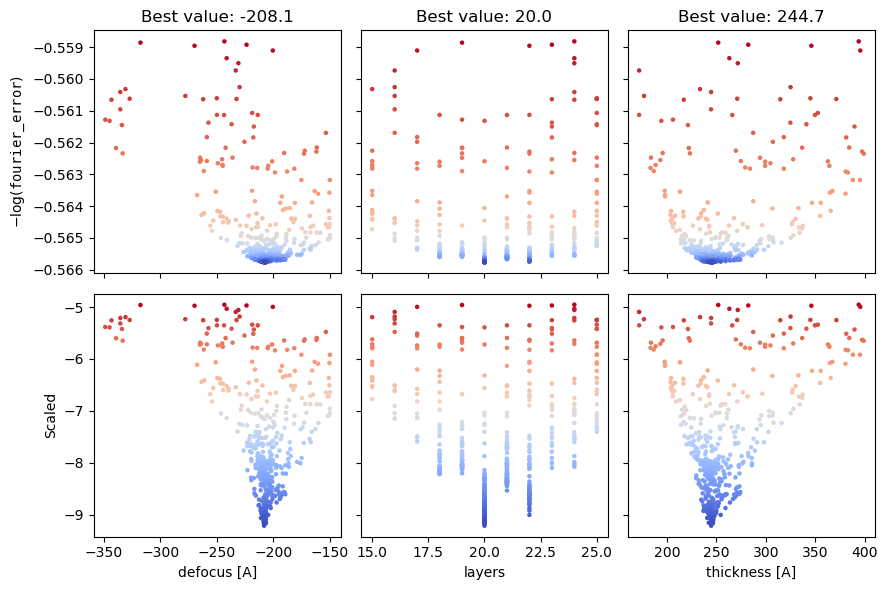

  Best BO index :          388
    defocus [A] :      -208.15
         layers :        20.00
  thickness [A] :       244.70
    log fourier :  -0.56577099


In [4]:
CMAP = 'coolwarm'

fig, axs = plt.subplots(2, len(x), figsize=(3*len(x), 6), sharey='row', sharex='col')
for i, axi in enumerate(axs[0]):
    axi.scatter(x[i][START:END], -y[START:END], c=y_scaled[START:END], cmap=CMAP, s=5)
    axi.set_title(f"Best value: {x[i,-1]:.1f}")

axs[0][0].set_ylabel('$- \\log (\\mathtt{fourier\\_error})$')

for i, axi in enumerate(axs[1]):
    axi.scatter(x[i][START:END], y_scaled[START:END], c=y_scaled[START:END], cmap=CMAP, s=5)
    axi.set_xlabel(xparams[i])
axs[1][0].set_ylabel('Scaled')
plt.tight_layout()
plt.show()

print(f"  Best BO index : {train_y.argmax():>12d}")
print("\n".join([f'{xparams[i]:>15} : {x[i, -1]:> 12.2f}' for i in range(len(xparams))]))
print(f"    log fourier : {-y[-1]: 12.8f}")

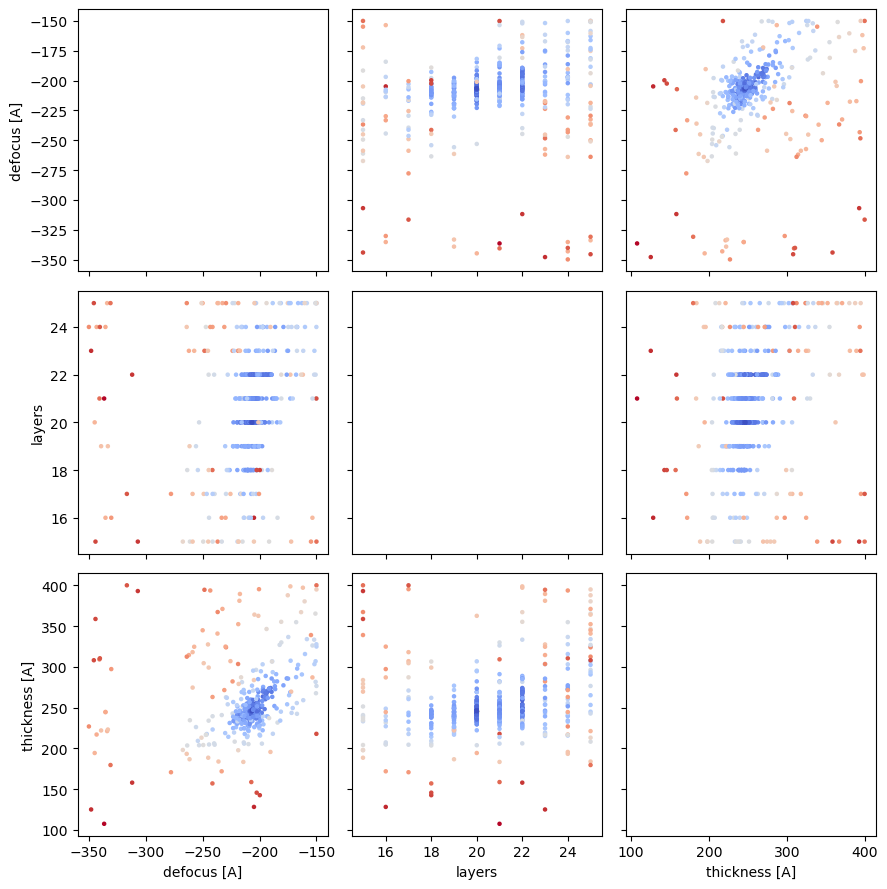

In [5]:
# Cross-correlation plots

if len(x) < 3:
    plt.figure(figsize=(3.5,3.5))
    plt.scatter(train_x[1][START:END], train_x[0][START:END], c=train_y_scaled[START:END], cmap=CMAP, s=5)
    plt.xlabel(xparams[1])
    plt.ylabel(xparams[0])
else:
    fig, axs = plt.subplots(len(x), len(x), figsize=(3*len(x), 3*len(x)), sharex='col', sharey='row')
    for i, axi in enumerate(axs):
        for j, axij in enumerate(axi):
            axij.scatter(train_x[j][START:END], train_x[i][START:END], c=train_y_scaled[START:END], cmap=CMAP, s=5, alpha=(0 if i==j else 1))
            if i == len(x)-1: axij.set_xlabel(xparams[j])
            if j == 0:        axij.set_ylabel(xparams[i])

plt.tight_layout()
plt.show()